표적지 점수 계산

In [3]:
from google.colab.patches import cv2_imshow
from google.colab import drive
import numpy as np
import cv2
import math
import matplotlib.pyplot as plt
drive.mount('/content/gdrive')

Mounted at /content/gdrive


(3668, 3668, 3)


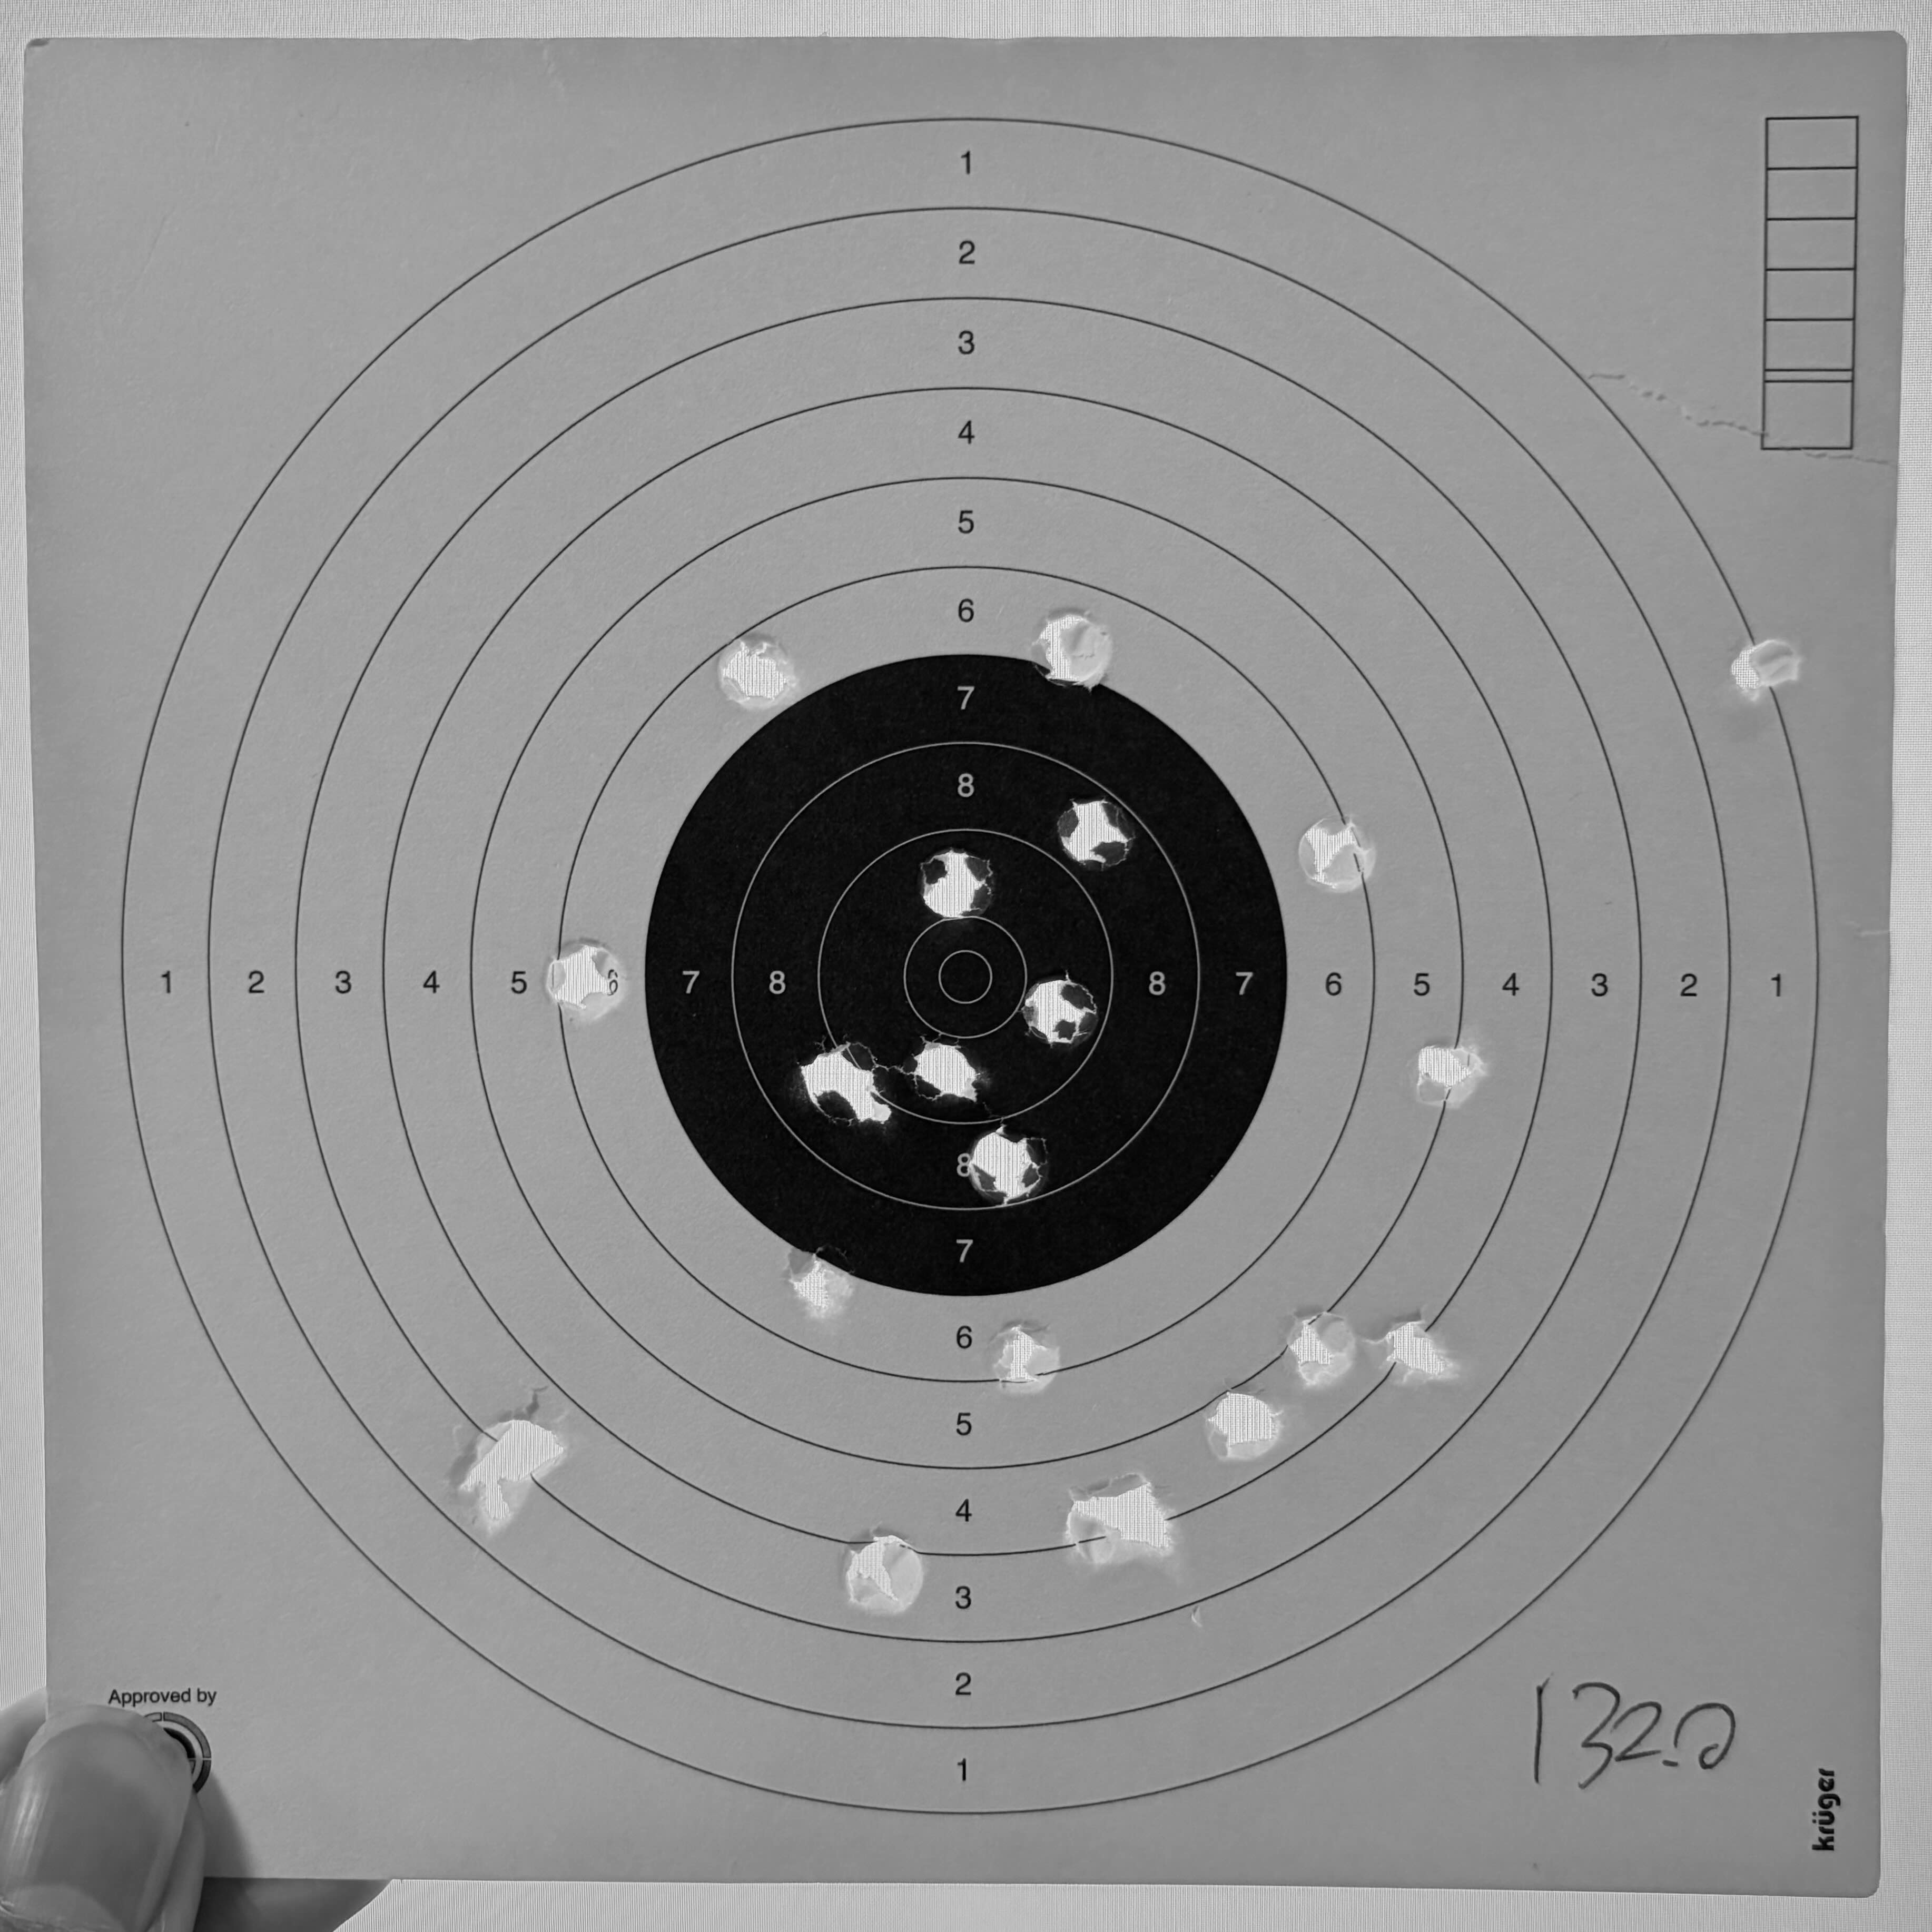

In [4]:
img = cv2.imread('/content/gdrive/My Drive/IP/Images/target2.jpg')
print(img.shape)
gImg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#plt.imshow(gImg, cmap='gray')
#plt.show()
height, width = img.shape[:2]
cv2_imshow(gImg)

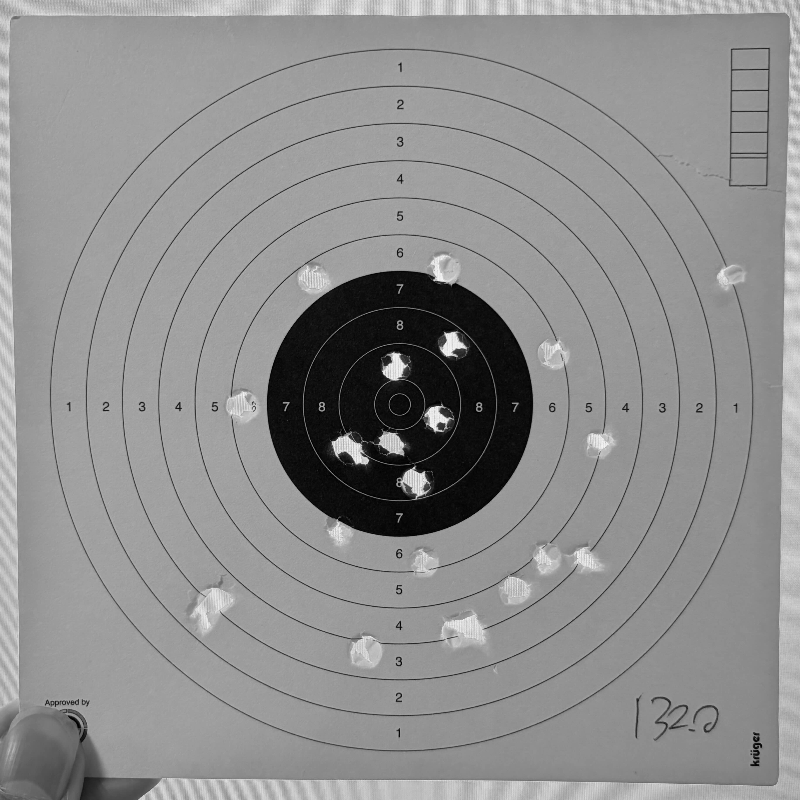

In [5]:
# 가로 너비 축소
width1 = 800
scale_ratio = width1 / width
heigh1 = int(height * scale_ratio)

# 그레이랑 컬러 이미지 작게 축소
gImg1 = cv2.resize(gImg, (width1, heigh1))
img1 = cv2.resize(img, (width1, heigh1))
h1, w1 = gImg1.shape

cv2_imshow(gImg1)

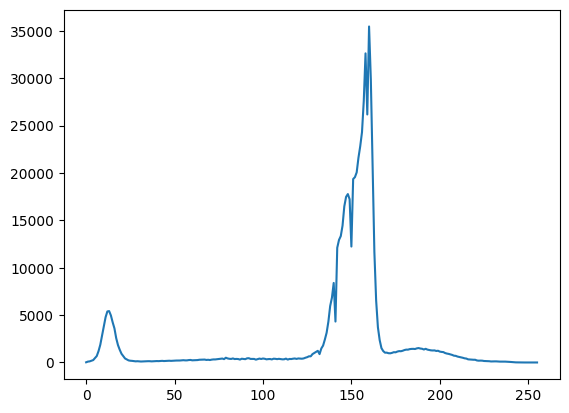

In [6]:
# 히스토그램 분석
hist = cv2.calcHist([gImg1], [0], None, [256], [0,255])
plt.plot(hist)

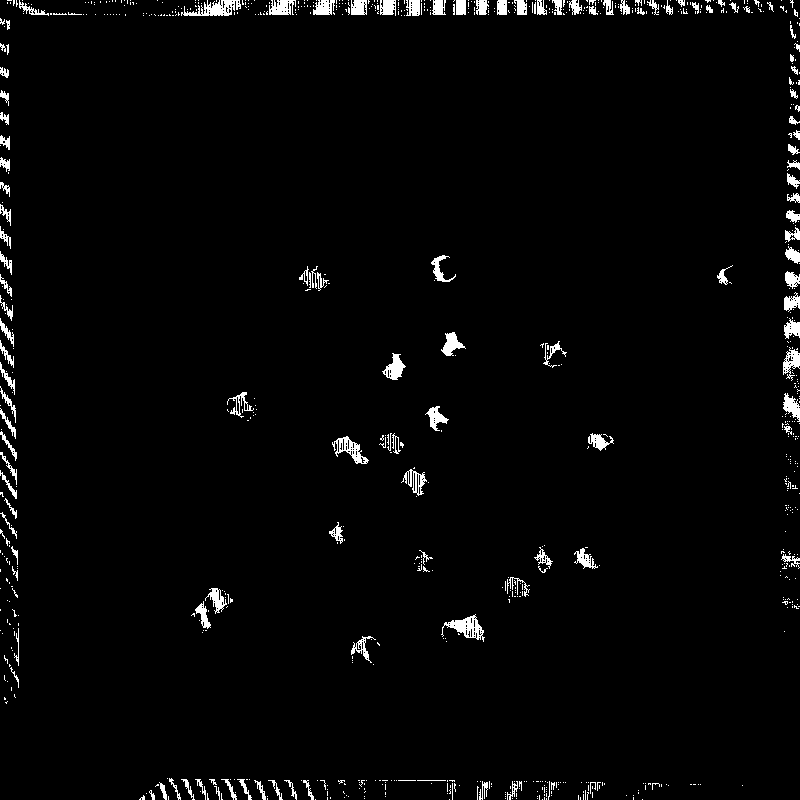

In [7]:
# 이진화 탄흔을 추출
gBin = cv2.threshold(gImg1, 200, 255, cv2.THRESH_BINARY)[1]
cv2_imshow(gBin)

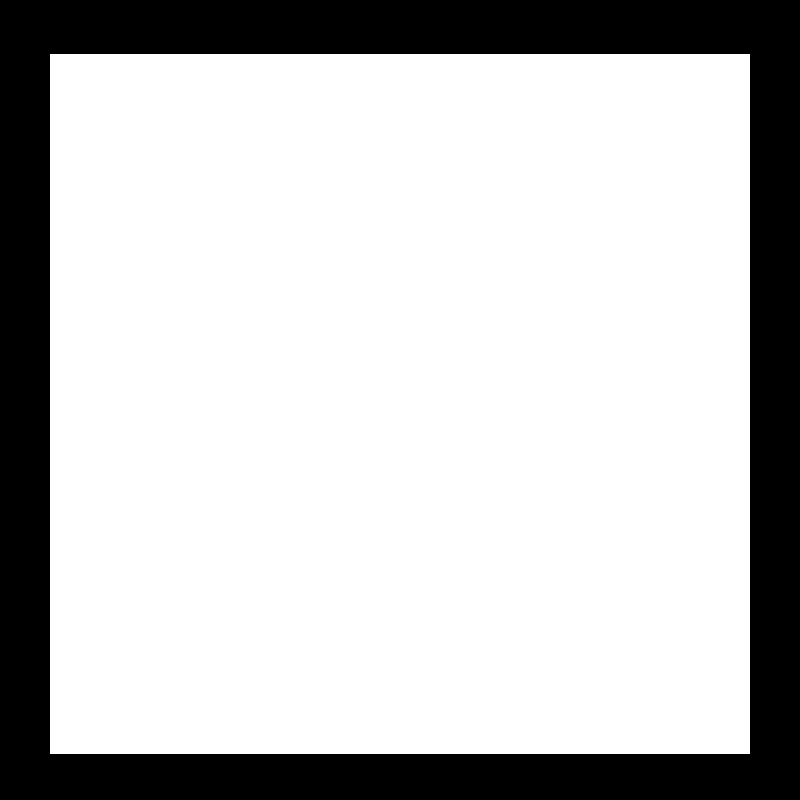

In [8]:
# 중심점 가져오기
target_center = (w1 // 2, h1 // 2 + 4)

# 마스크 크기 설정
mask_w, mask_h = 700, 700
x1 = target_center[0] - mask_w // 2
y1 = target_center[1] - mask_h // 2
x2 = target_center[0] + mask_w // 2
y2 = target_center[1] + mask_h // 2

x1 = max(0, x1); y1 = max(0, y1)
x2 = min(w1, x2); y2 = min(h1, y2)

# 마스크 생성
mask = np.zeros_like(gBin, dtype=np.uint8)
mask[y1:y2, x1:x2] = 255

cv2_imshow(mask)

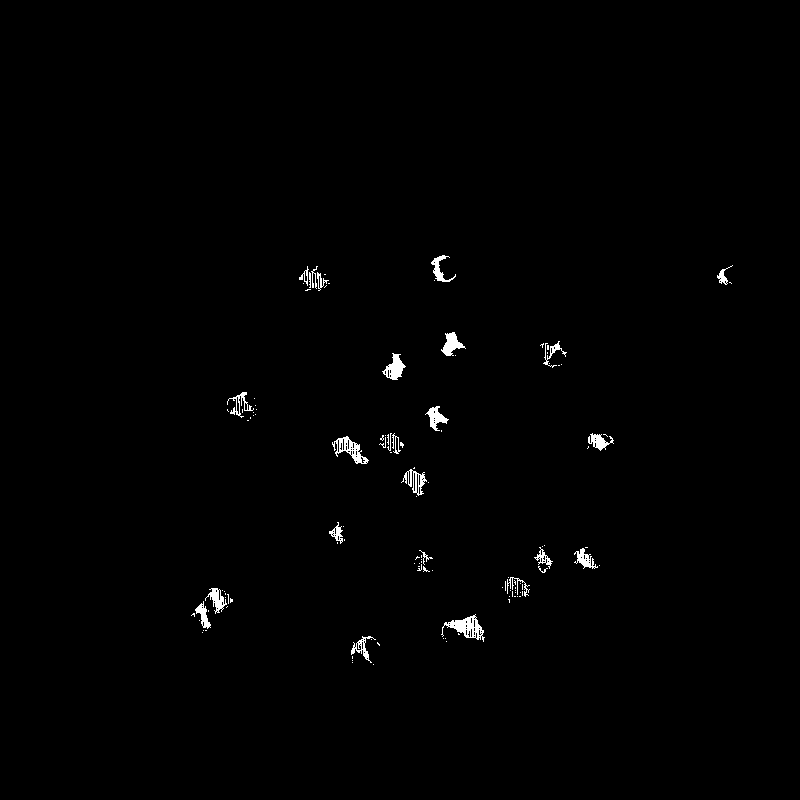

In [9]:
# 마스크 영역 외 제거
gBin_masked = cv2.bitwise_and(gBin, gBin, mask=mask)
cv2_imshow(gBin_masked)

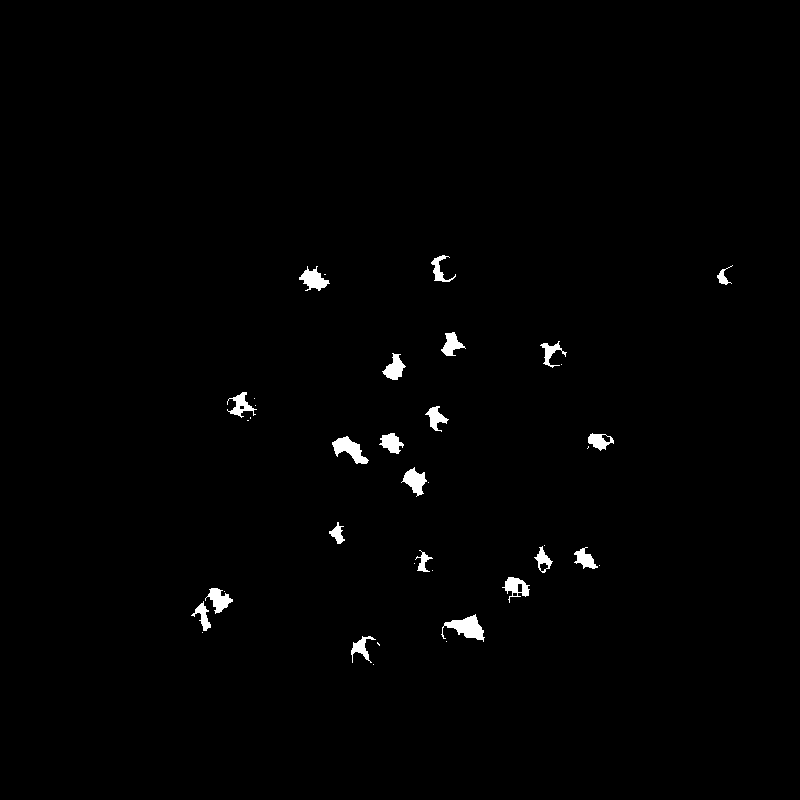

In [10]:
# 모폴로지 연산 (닫힘 연산)
kernel = np.ones((3, 3), np.uint8)
gBin_cleaned = cv2.morphologyEx(gBin_masked, cv2.MORPH_CLOSE, kernel)
cv2_imshow(gBin_cleaned)

In [11]:
# 외곽선 검출
contours, _ = cv2.findContours(
    gBin_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

print("검출된 외곽선의 수 :", len(contours))


검출된 외곽선의 수 : 38


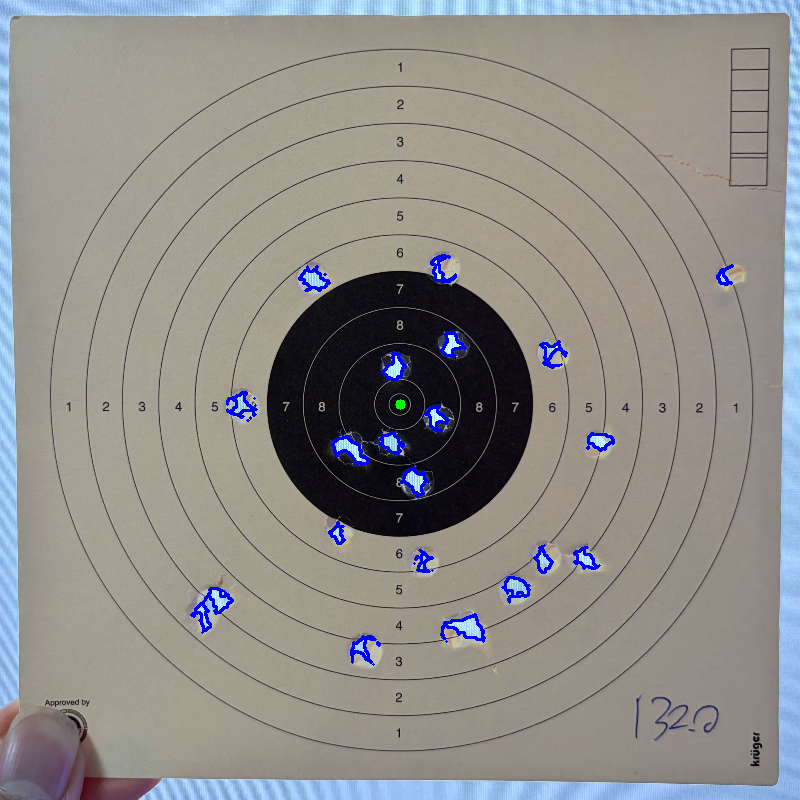

In [12]:
center = img1.copy()

# 외곽선 그리기
cv2.drawContours(center, contours, -1, (255, 0, 0), 2)

# 중심점 표시
cv2.circle(center, target_center, 5, (0, 255, 0), -1)

# 결과 이미지 출력
cv2_imshow(center)

In [13]:
#점수 계산 함수
def get_score(distance):
    if distance < 40: return 9
    elif distance < 80: return 8
    elif distance < 120: return 7
    elif distance < 165: return 6
    elif distance < 205: return 5
    elif distance < 245: return 4
    elif distance < 285: return 3
    elif distance < 320: return 2
    elif distance < 360: return 1
    elif distance < 400: return 0
    return 0


In [14]:
result_img = img1.copy()
total_score = 0
valid_contours = 0

for cnt in contours:
    area = cv2.contourArea(cnt)

    # 너무 작거나 큰 노이즈 제거
    if area < 50 or area > 3000:
        continue

    # 중심 좌표
    M = cv2.moments(cnt)
    if M['m00'] == 0:
        continue

    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])

    # 표적 중심과의 거리 계산
    dist = math.hypot(cx - target_center[0], cy - target_center[1])

    # 점수 계산
    score = get_score(dist)
    total_score += score
    valid_contours += 1

    # 시각화
    cv2.drawContours(result_img, [cnt], -1, (255, 0, 0), 2)
    cv2.circle(result_img, (cx, cy), 3, (0, 0, 255), -1)
    cv2.putText(result_img, str(score), (cx + 10, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

print("탄흔 개수:", valid_contours)
print("총 점수:", total_score)


탄흔 개수: 21
총 점수: 117


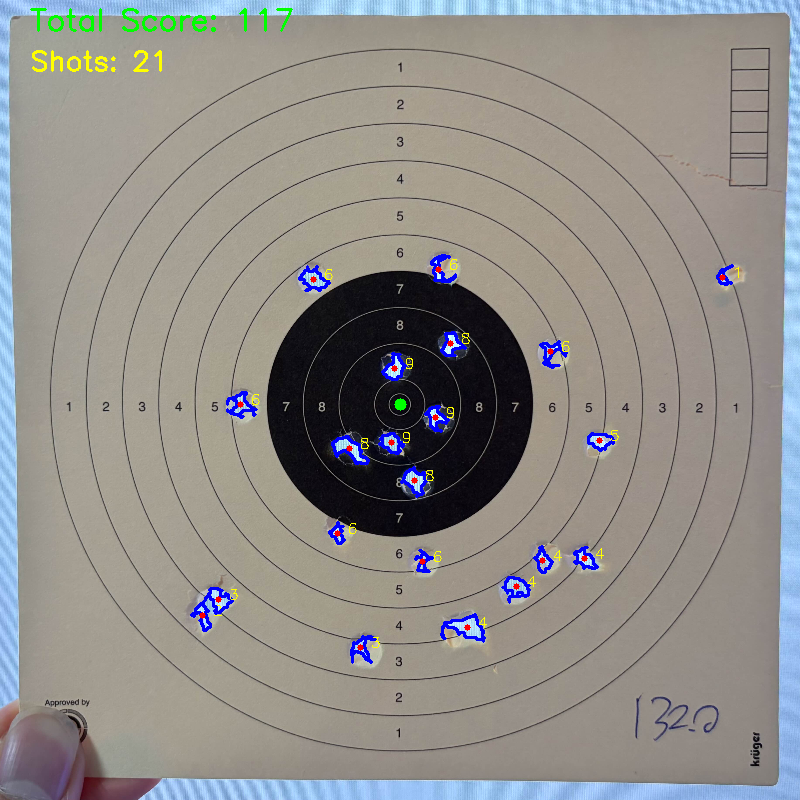

In [15]:
# 총점 표시
cv2.putText(result_img, f"Total Score: {total_score}", (30, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# 총알 개수 표시
cv2.putText(result_img, f"Shots: {valid_contours}", (30, 70),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)

# 표적지 중심점 표시
cv2.circle(result_img, target_center, 6, (0, 255, 0), -1)

# 결과 이미지 출력
cv2_imshow(result_img)